# Sales Prediction Using Python
### Task 2 — OIBSIP Data Science Internship

**Objective:** Build a regression model that predicts product sales based on advertising spend across three media channels — TV, Radio, and Newspaper.

**Dataset:** This is the classic "Advertising" dataset originally published in *An Introduction to Statistical Learning* (James, Witten, Hastie, Tibshirani). It contains 200 markets, each with recorded advertising spend (in thousands of dollars) across TV, Radio, and Newspaper, alongside the resulting product sales (in thousands of units).


In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make plots render inline and look clean
%matplotlib inline
sns.set(style="whitegrid")


## 1. Load the Dataset

The dataset is loaded from a CSV file (`Advertising.csv`). The first column is an unnamed index column from the original source, which we drop since pandas already provides its own index.

In [2]:
# Load the dataset
df = pd.read_csv("./dataset/Advertising.csv")

# The first column (originally unnamed) is just a row index from the source file.
# We drop it here since pandas already gives every row its own index automatically.
df = df.drop(columns=[df.columns[0]])

# Preview the first five rows to confirm it loaded correctly
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 2. Exploratory Data Analysis (EDA)

Before building any model, we need to understand the data: its shape, whether any values are missing, and how the numbers are distributed.

In [3]:
# Shape of the dataset: (number of rows, number of columns)
print("Shape of the dataset:", df.shape)


Shape of the dataset: (200, 4)


In [4]:
# Check for any missing (null) values in each column.
# If this shows any number greater than 0, we would need to handle missing data
# before modeling. For this dataset, we expect all zeros.
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [5]:
# Descriptive statistics: count, mean, standard deviation, min, max, and quartiles
# for every numeric column. This gives a quick sense of the scale and spread
# of each advertising channel and of Sales itself.
df.describe()


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
# Data types of each column — confirms everything is numeric, as expected
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


C:\Users\DEII\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DEII\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DEII\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DEII\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

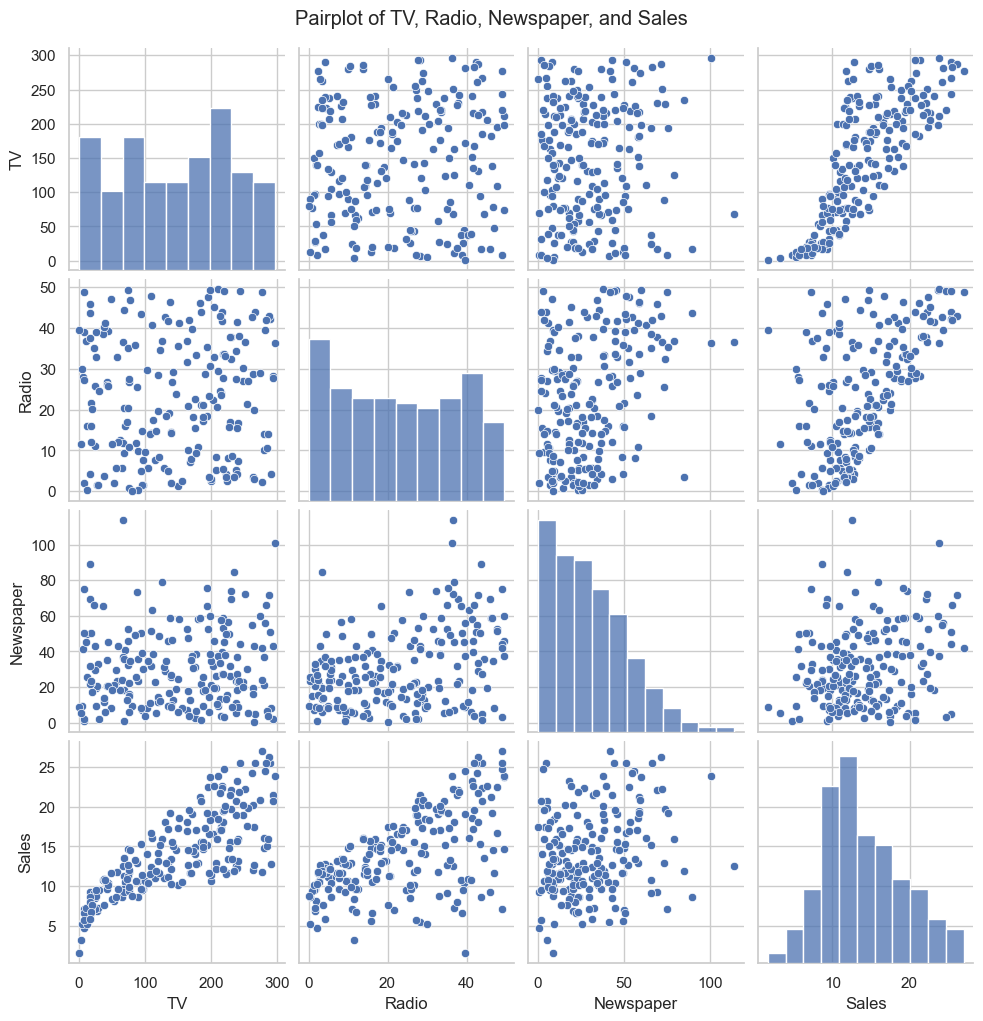

In [8]:
# Pairplot: shows every feature plotted against every other feature (and against
# itself as a histogram on the diagonal). This is a fast way to spot linear
# relationships and any obvious outliers before we build a model.
sns.pairplot(df)
plt.suptitle("Pairplot of TV, Radio, Newspaper, and Sales", y=1.02)
plt.show()


## 3. Individual Scatter Plots — Sales vs. Each Channel

The pairplot above shows everything at once. Here we isolate each advertising channel against Sales individually, since that's the specific relationship we ultimately care about predicting.

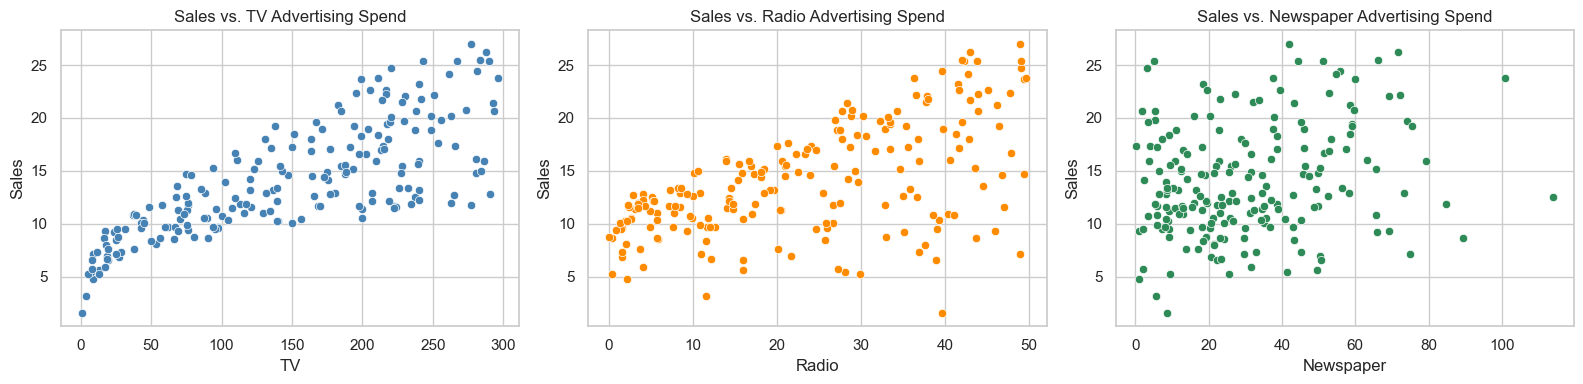

In [9]:
# Create one row of three scatter plots side by side, one per advertising channel
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.scatterplot(x="TV", y="Sales", data=df, ax=axes[0], color="steelblue")
axes[0].set_title("Sales vs. TV Advertising Spend")

sns.scatterplot(x="Radio", y="Sales", data=df, ax=axes[1], color="darkorange")
axes[1].set_title("Sales vs. Radio Advertising Spend")

sns.scatterplot(x="Newspaper", y="Sales", data=df, ax=axes[2], color="seagreen")
axes[2].set_title("Sales vs. Newspaper Advertising Spend")

plt.tight_layout()
plt.show()


**What to look for:** TV spend shows the clearest, most linear-looking relationship with Sales. Radio shows a weaker but still visible positive trend. Newspaper looks the noisiest of the three, with sales scattered fairly widely even at similar spend levels — a signal that Newspaper may end up being the least useful predictor.

## 4. Correlation Matrix Heatmap

This quantifies what the scatter plots showed visually — how strongly each pair of variables moves together, on a scale from -1 to 1.

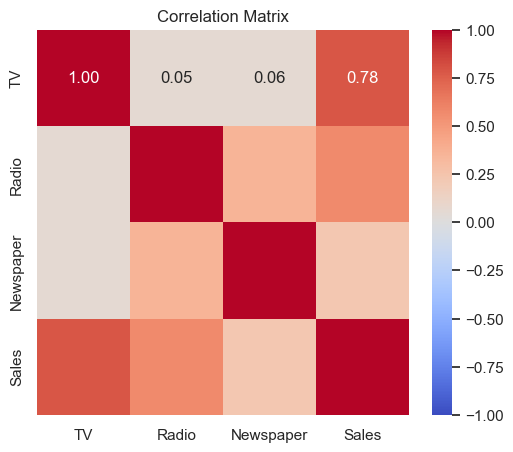

In [10]:
# Compute the correlation matrix: how strongly each pair of columns is related
corr_matrix = df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()


**Reading this heatmap:** TV has the strongest correlation with Sales, followed by Radio, with Newspaper showing the weakest relationship. The advertising channels themselves are only weakly correlated with each other, which is good news for a regression model — it means each channel is contributing largely independent information, rather than the model struggling to tell two very similar features apart.

## 5. Train/Test Split

We hold back a portion of the data (the test set) that the model never sees during training. This lets us honestly evaluate how well the model generalizes to new, unseen markets — rather than just how well it memorized the data it was trained on.

In [11]:
# Features (X): the three advertising channels
# Target (y): Sales, the value we are trying to predict
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

# Split into 80% training data and 20% test data.
# random_state=42 makes the split reproducible — running this cell again
# will always produce the exact same split, which matters for fair comparison
# if we test more models later.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0], "markets")
print("Test set size:", X_test.shape[0], "markets")


Training set size: 160 markets
Test set size: 40 markets


## 6. Train a Linear Regression Model (Baseline)

Linear Regression is a natural starting point here: it assumes Sales can be explained as a weighted sum of the three advertising channels, which is easy to interpret and gives us a baseline to compare any more complex model against later.

In [12]:
# Create and train the Linear Regression model on the training data
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")


Model trained successfully.


In [13]:
# Look at what the model actually learned: one coefficient per feature,
# plus an intercept. Each coefficient tells us how much Sales is predicted
# to change for every one-unit increase in that channel's spend, holding
# the other two channels constant.
coefficients = pd.DataFrame(
    model.coef_, index=X.columns, columns=["Coefficient"]
)
print(coefficients)
print("\nIntercept:", model.intercept_)


           Coefficient
TV            0.044730
Radio         0.189195
Newspaper     0.002761

Intercept: 2.979067338122631


**Interpreting the coefficients:** the TV coefficient being noticeably larger than Radio's, which in turn is larger than Newspaper's, mirrors exactly what the correlation heatmap suggested — TV spend has the strongest relationship with Sales, Newspaper the weakest.

In [14]:
# Use the trained model to predict Sales on the test set (data it has never seen)
y_pred = model.predict(X_test)

# Evaluate how close the predictions were to the actual values, using three
# standard regression metrics:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):  {mae:.3f}")
print(f"Mean Squared Error (MSE):   {mse:.3f}")
print(f"Root Mean Squared Error:    {rmse:.3f}")
print(f"R-squared (R^2) Score:      {r2:.3f}")


Mean Absolute Error (MAE):  1.461
Mean Squared Error (MSE):   3.174
Root Mean Squared Error:    1.782
R-squared (R^2) Score:      0.899


**What these numbers mean:**
- **MAE** is the average size of the prediction error, in the same units as Sales (thousands of units) — easy to interpret directly.
- **RMSE** penalizes large errors more heavily than MAE, so a big gap between the two would suggest a few predictions were badly off.
- **R² Score** tells us what proportion of the variation in Sales is explained by the three advertising channels together. A value close to 1 means the model explains most of the variation; closer to 0 means it explains very little.

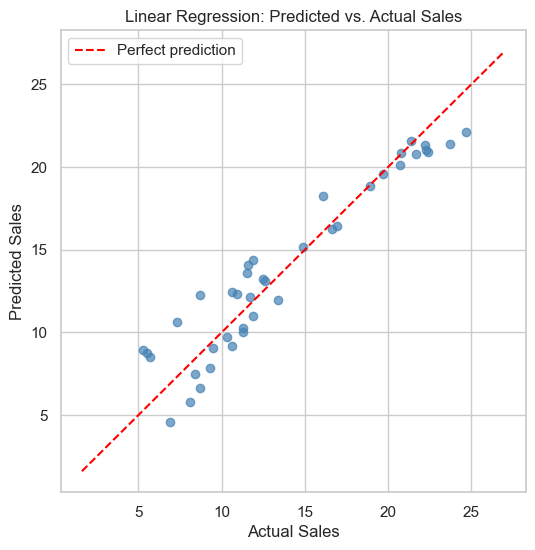

In [15]:
# Visualize predicted vs. actual sales. Points sitting close to the diagonal
# red line mean the model's predictions were close to the true values.
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color="steelblue", alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Linear Regression: Predicted vs. Actual Sales")
plt.legend()
plt.show()


## Conclusion

The baseline Linear Regression model captures the relationship between advertising spend and sales reasonably well, with TV emerging as the strongest driver, Radio a meaningful secondary contributor, and Newspaper the weakest of the three — consistent across the EDA, the correlation heatmap, and the model's own coefficients. As a next step, this baseline could be compared against a more flexible model (such as Random Forest or a polynomial regression) to check whether the relationship between spend and sales is fully linear, or whether some diminishing-returns effect is being missed.